# 03 — Exploratory Data Analysis | NYC Rolling Sales
> Cleaned dataset · Engineered features included · No statistical tests

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import matplotlib.ticker as mtick
import warnings; warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'axes.titleweight': 'bold', 'axes.titlesize': 13})
PAL = ['#4C72B0','#55A868','#C44E52','#8172B3','#CCB974']

df = pd.read_csv('../data/processed/cleaned_data.csv')
df['sale_date'] = pd.to_datetime(df['sale_date'])

SIZE_ORD = ['Small','Medium','Mid-Large','Large','Very Large']
BORO_ORD = ['Manhattan','Brooklyn','Queens','Bronx','Staten Island']
PRICE_ORD = ['<250K','250K-500K','500K-1M','1M-2.5M','2.5M-5M','5M+']

print(f"Shape: {df.shape}")
df.head()

Shape: (57601, 31)


,borough,borough_name,neighborhood,zip_code,building_class_category,building_class_code,building_class_description,building_class_at_present,building_class_at_time_of_sale,tax_class_at_present,...,sale_quarter,sale_day_of_week,price_per_sqft,price_per_unit,building_age,floor_area_ratio,is_residential,has_units,size_category,price_bracket
0,1,Manhattan,ALPHABET CITY,10009,07 RENTALS - WALKUP APARTMENTS,07,RENTALS - WALKUP APARTMENTS,C2,C2,2A,...,3,Wednesday,1028.726708,1.325000e+06,117.0,3.943662,1,1,Large,5M+
1,1,Manhattan,ALPHABET CITY,10009,07 RENTALS - WALKUP APARTMENTS,07,RENTALS - WALKUP APARTMENTS,C4,C4,2B,...,3,Friday,579.374742,3.936272e+05,103.0,2.990317,1,1,Large,2.5M-5M
2,1,Manhattan,ALPHABET CITY,10009,07 RENTALS - WALKUP APARTMENTS,07,RENTALS - WALKUP APARTMENTS,C2,C2,2A,...,4,Thursday,1733.477790,1.333333e+06,116.0,1.948079,1,1,Mid-Large,5M+
3,1,Manhattan,ALPHABET CITY,10009,07 RENTALS - WALKUP APARTMENTS,07,RENTALS - WALKUP APARTMENTS,C4,C4,2B,...,3,Friday,755.522953,3.991050e+05,96.0,2.414857,1,1,Mid-Large,2.5M-5M
4,1,Manhattan,ALPHABET CITY,10009,08 RENTALS - ELEVATOR APARTMENTS,08,RENTALS - ELEVATOR APARTMENTS,D1,D1,2B,...,4,Monday,838.056680,1.035000e+06,7.0,3.322572,1,1,Very Large,5M+


## 1 · Univariate Analysis

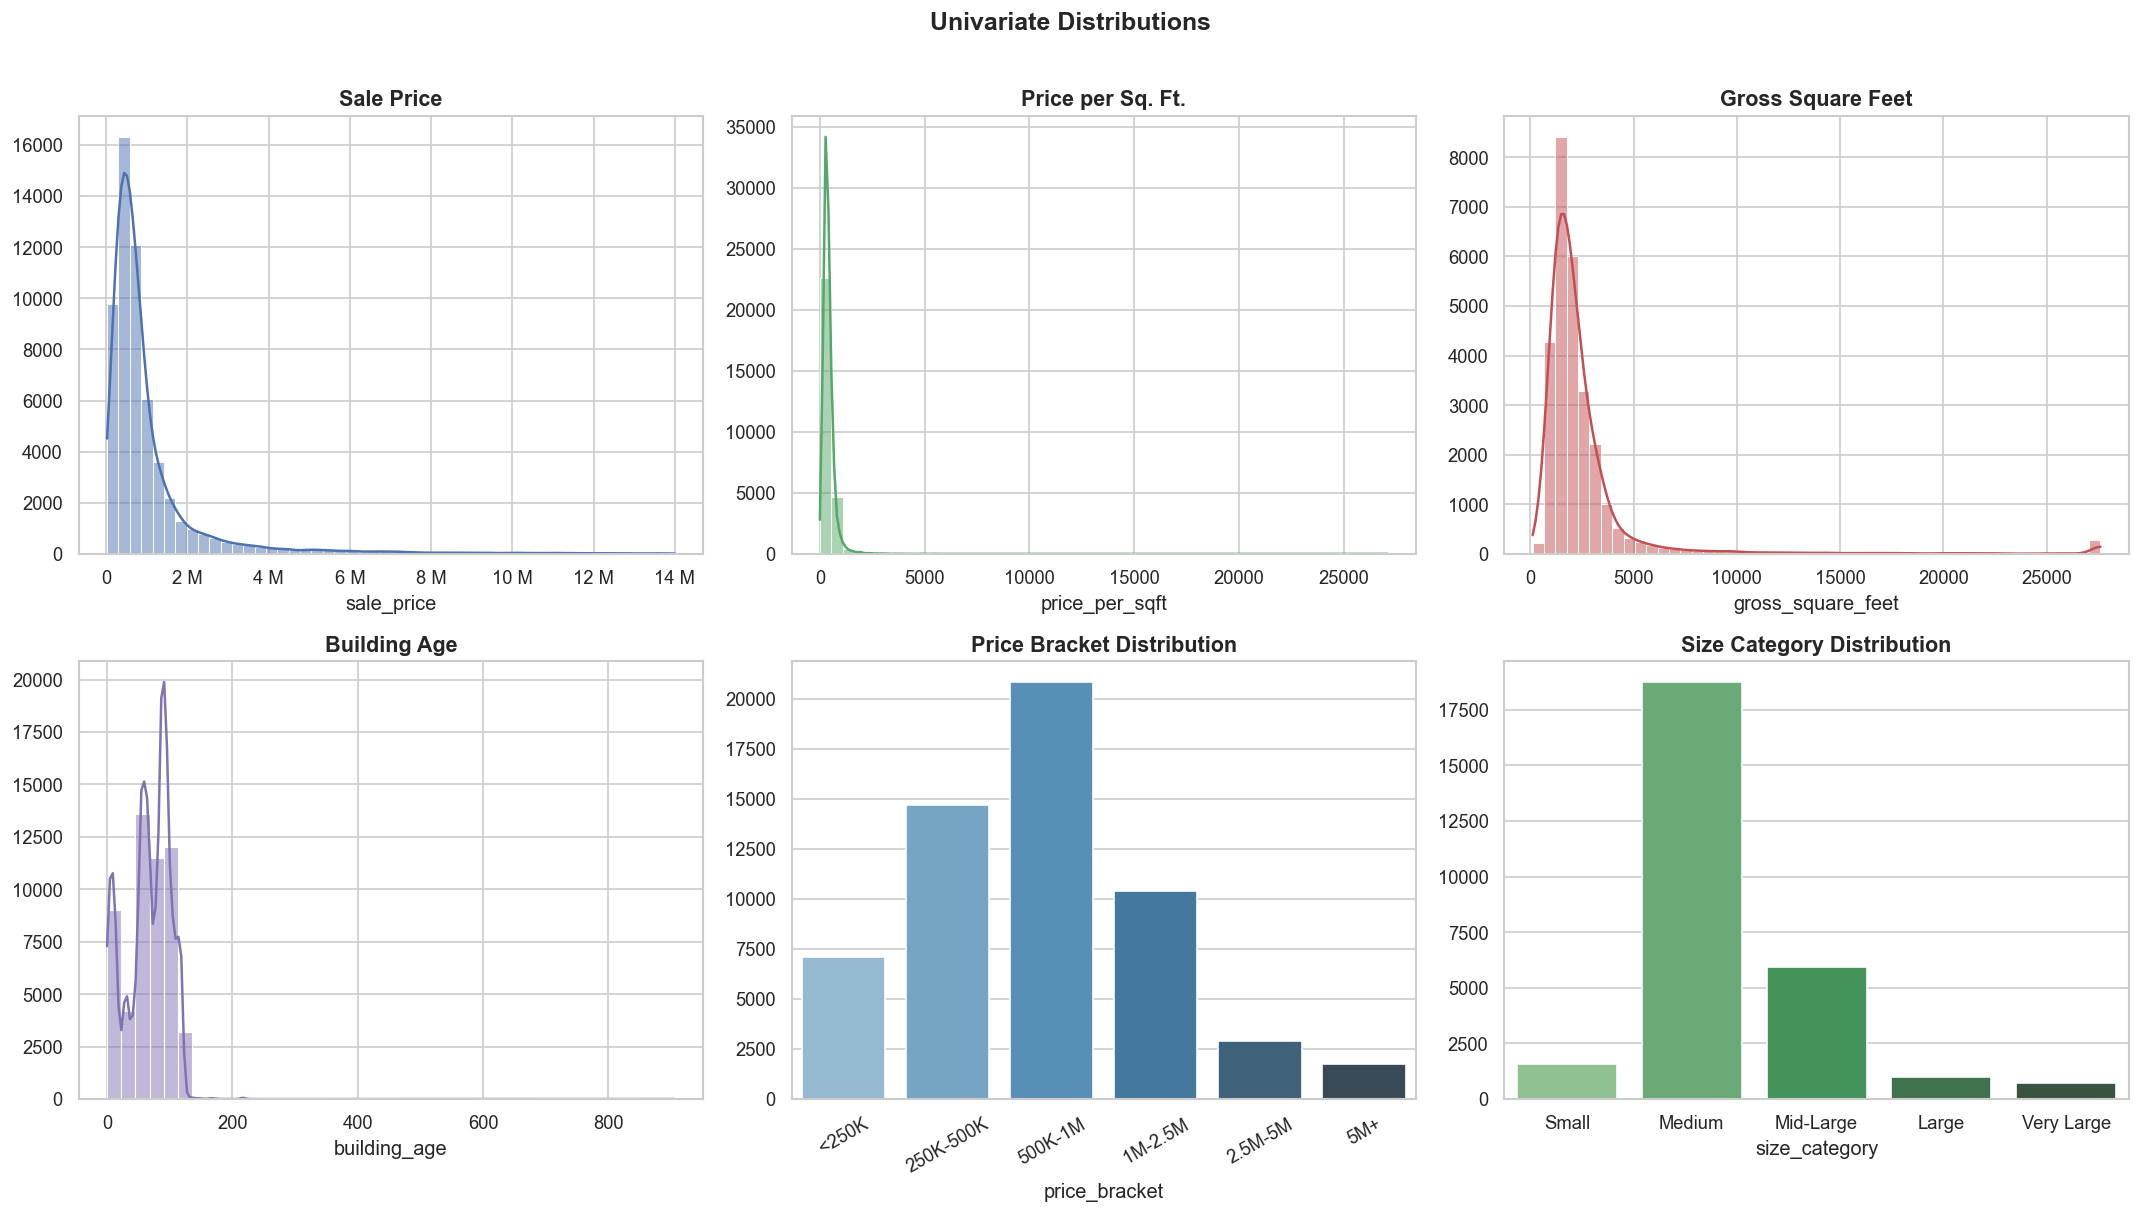

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Sale Price
sns.histplot(df['sale_price'], bins=50, kde=True, ax=axes[0,0], color=PAL[0])
axes[0,0].set_title('Sale Price'); axes[0,0].xaxis.set_major_formatter(mtick.EngFormatter())

# Price per Sqft
sns.histplot(df['price_per_sqft'].dropna(), bins=50, kde=True, ax=axes[0,1], color=PAL[1])
axes[0,1].set_title('Price per Sq. Ft.')

# Gross Square Feet
sns.histplot(df['gross_square_feet'].dropna(), bins=50, kde=True, ax=axes[0,2], color=PAL[2])
axes[0,2].set_title('Gross Square Feet')

# Building Age
sns.histplot(df['building_age'].dropna(), bins=40, kde=True, ax=axes[1,0], color=PAL[3])
axes[1,0].set_title('Building Age')

# Price Bracket counts
sns.countplot(data=df, x='price_bracket', order=PRICE_ORD, palette='Blues_d', ax=axes[1,1])
axes[1,1].set_title('Price Bracket Distribution'); axes[1,1].tick_params(axis='x', rotation=30)

# Size Category counts
sns.countplot(data=df, x='size_category', order=SIZE_ORD, palette='Greens_d', ax=axes[1,2])
axes[1,2].set_title('Size Category Distribution')

for ax in axes.flat: ax.set_ylabel('')
plt.suptitle('Univariate Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

> Most sales fall in the $250K–$1M range. Price per sqft clusters around $200–$600, showing a tighter "true market rate" than raw prices. Building age has a distinct peak around 80–100 yrs (NYC's pre-war housing stock).

## 2 · Outlier Detection

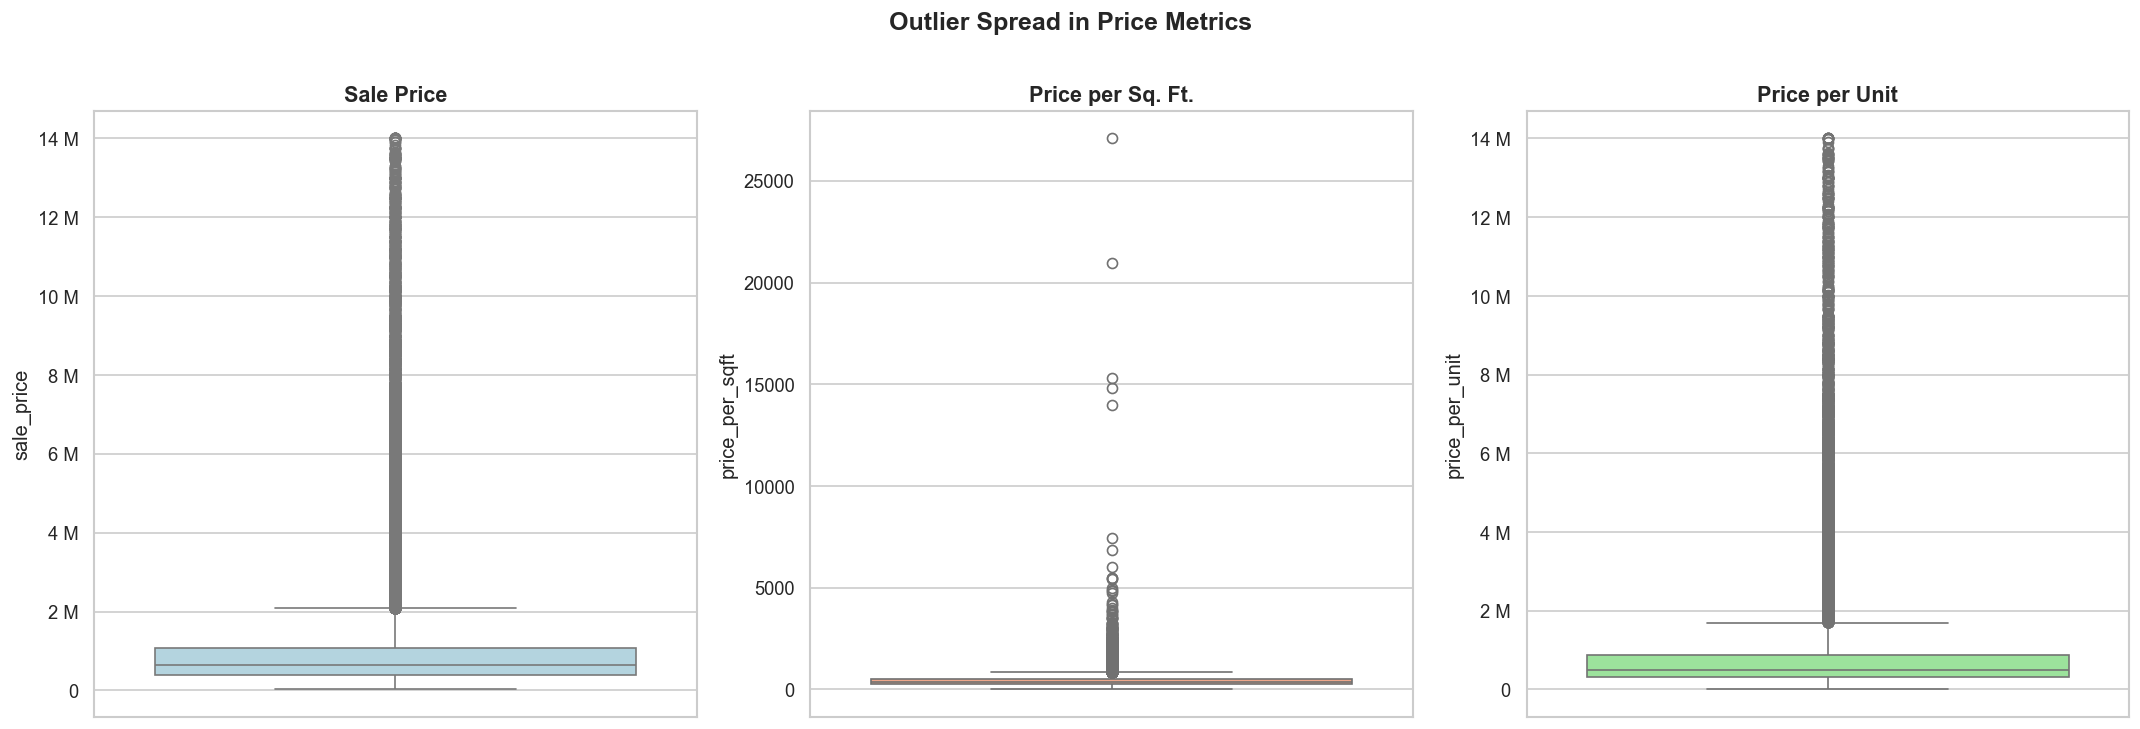

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(y=df['sale_price'], ax=axes[0], color='lightblue')
axes[0].set_title('Sale Price'); axes[0].yaxis.set_major_formatter(mtick.EngFormatter())

sns.boxplot(y=df['price_per_sqft'].dropna(), ax=axes[1], color='lightsalmon')
axes[1].set_title('Price per Sq. Ft.')

sns.boxplot(y=df['price_per_unit'].dropna(), ax=axes[2], color='lightgreen')
axes[2].set_title('Price per Unit'); axes[2].yaxis.set_major_formatter(mtick.EngFormatter())

plt.suptitle('Outlier Spread in Price Metrics', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

> Even after 1st/99th percentile capping, all three price metrics show upper-end outliers driven by Manhattan's luxury segment. Median sits low — the market is dominated by standard residential transactions.

## 3 · Bivariate Analysis

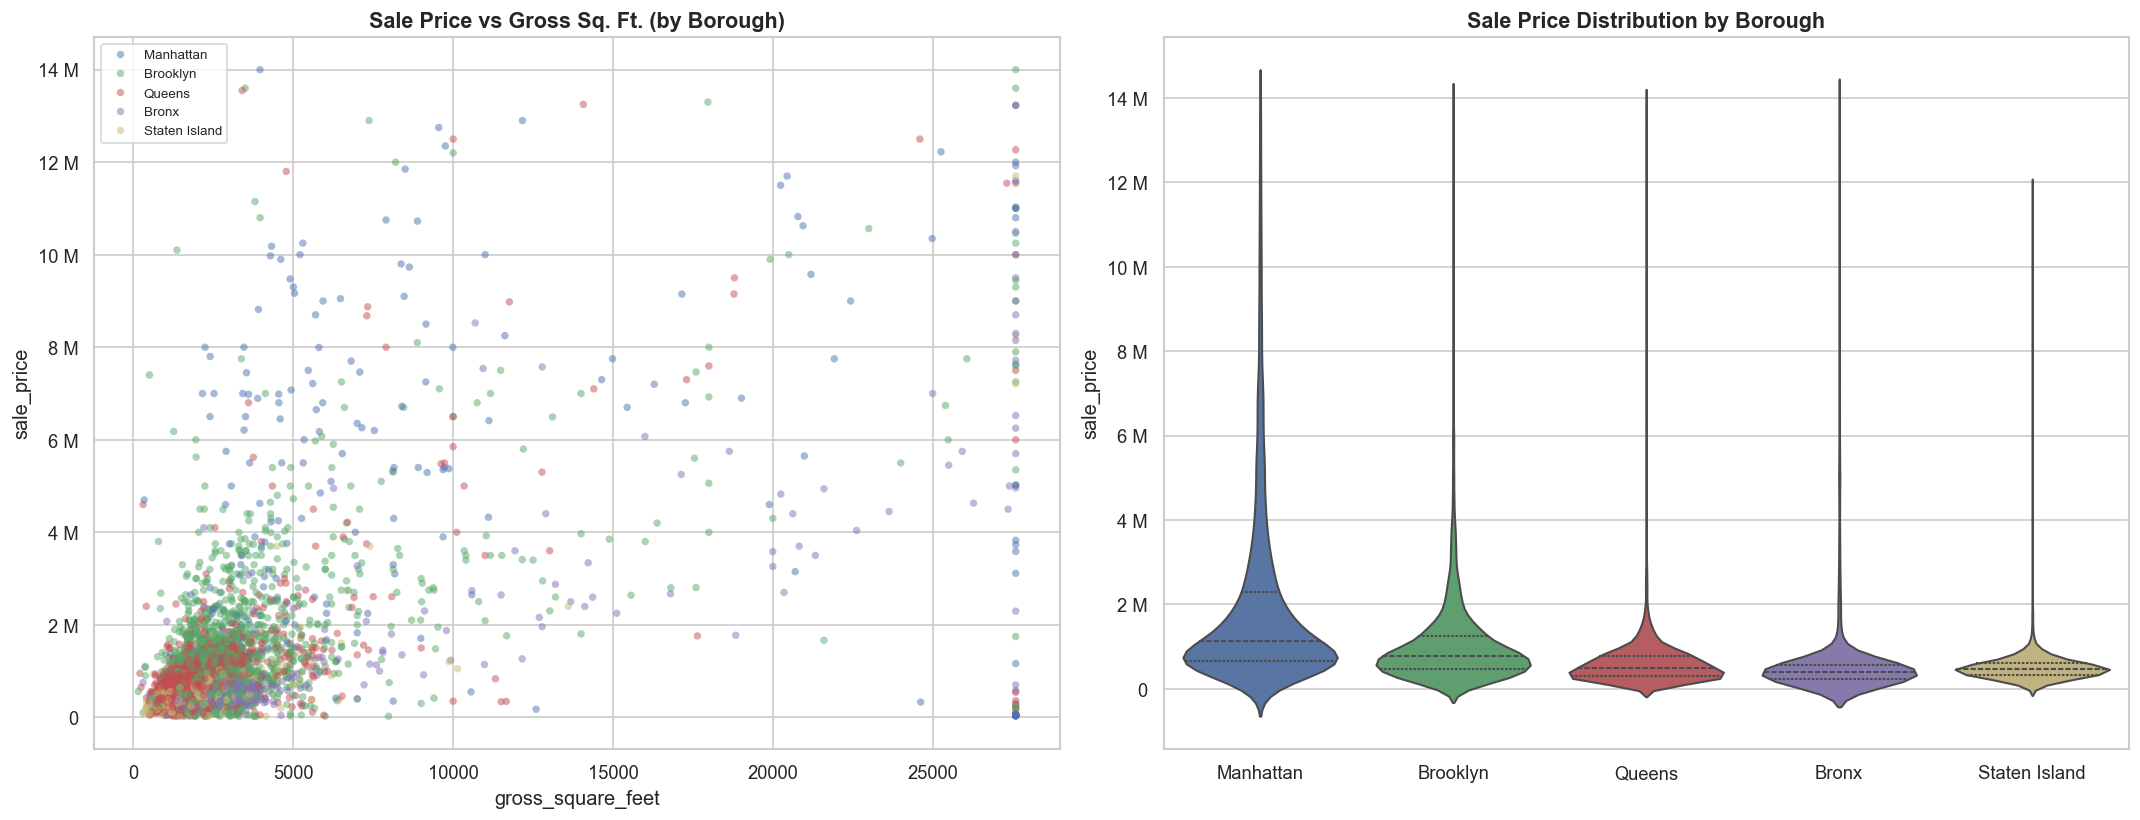

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Scatter: Price vs Size
sample = df.dropna(subset=['gross_square_feet']).sample(min(8000, len(df)), random_state=42)
sns.scatterplot(data=sample, x='gross_square_feet', y='sale_price', hue='borough_name',
                hue_order=BORO_ORD, palette=PAL, alpha=0.5, s=20, ax=axes[0], edgecolor='none')
axes[0].set_title('Sale Price vs Gross Sq. Ft. (by Borough)')
axes[0].yaxis.set_major_formatter(mtick.EngFormatter())
axes[0].legend(fontsize=8, title_fontsize=9)

# Violin: Price by Borough
sns.violinplot(data=df, x='borough_name', y='sale_price', order=BORO_ORD,
               palette=PAL, inner='quartile', ax=axes[1])
axes[1].set_title('Sale Price Distribution by Borough')
axes[1].yaxis.set_major_formatter(mtick.EngFormatter()); axes[1].set_xlabel('')

plt.tight_layout(); plt.show()

> Manhattan dominates the upper range at every property size. The violin plot reveals Brooklyn has a wide mid-range spread while Bronx/Staten Island are tightly clustered at the bottom.

## 4 · Engineered Feature Analysis

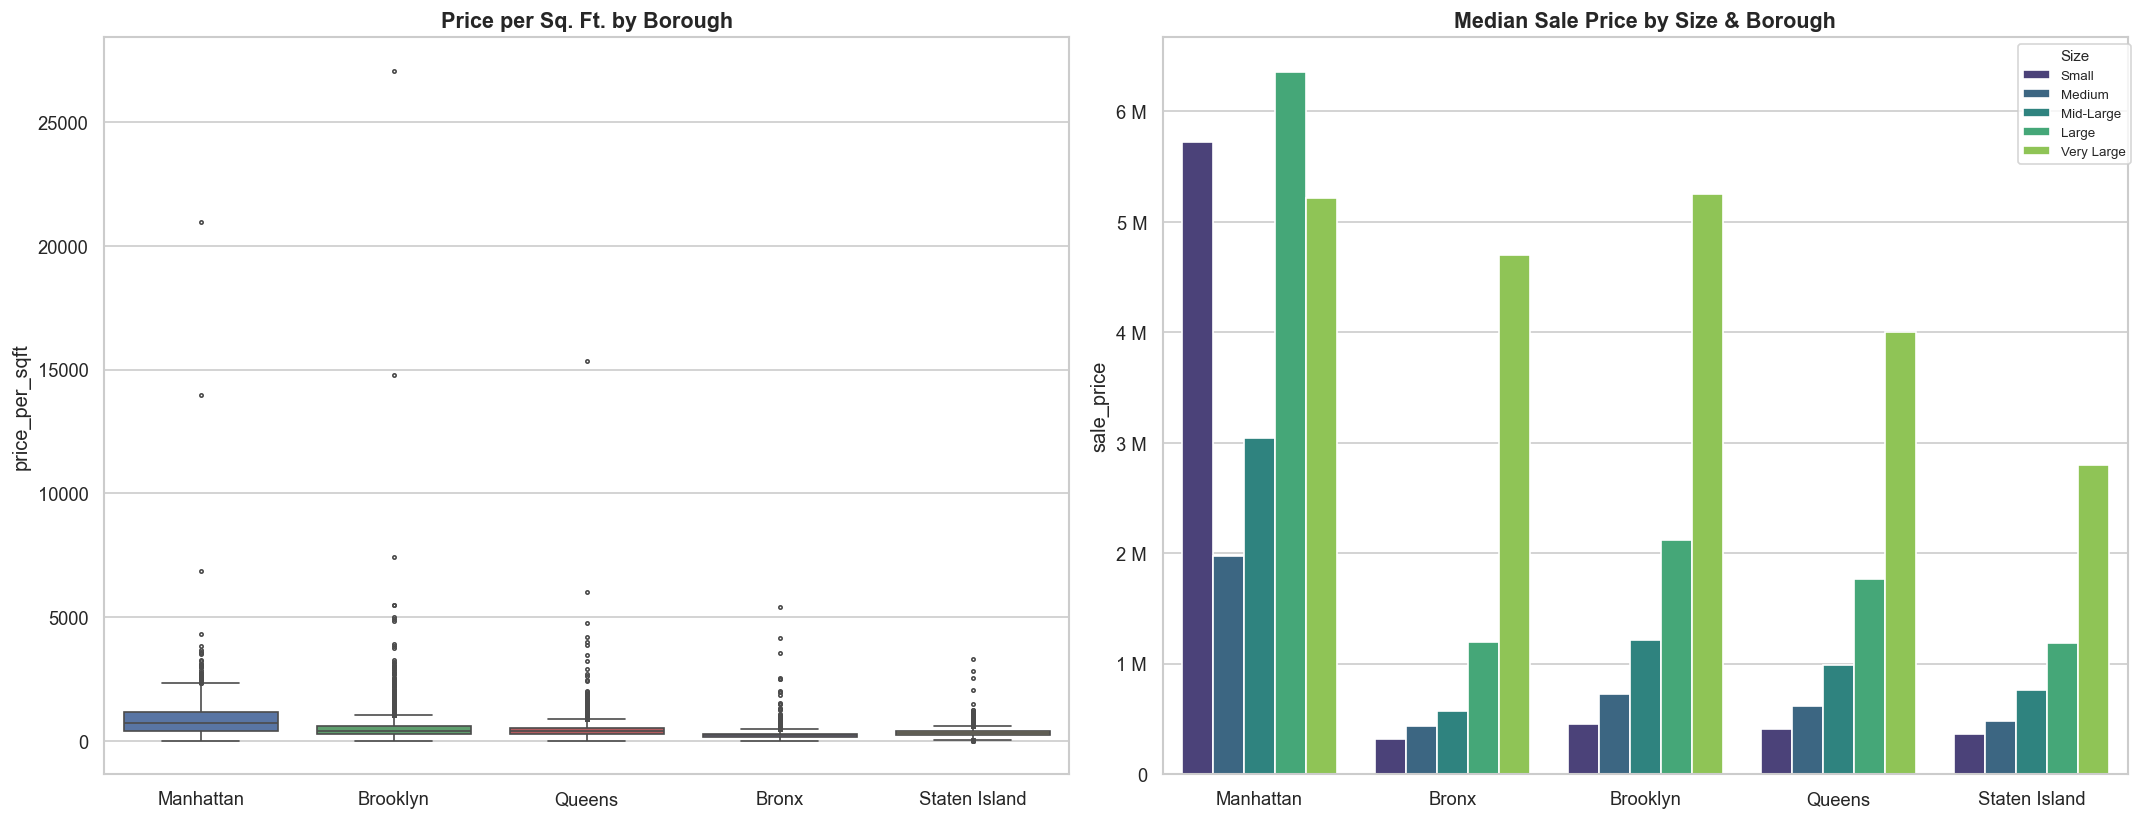

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Price/sqft by Borough
sns.boxplot(data=df, x='borough_name', y='price_per_sqft', order=BORO_ORD, palette=PAL, fliersize=2, ax=axes[0])
axes[0].set_title('Price per Sq. Ft. by Borough'); axes[0].set_xlabel('')

# Median price by size category + borough
sns.barplot(data=df, x='borough_name', y='sale_price', hue='size_category',
            hue_order=SIZE_ORD, estimator=np.median, errorbar=None, palette='viridis', ax=axes[1])
axes[1].set_title('Median Sale Price by Size & Borough')
axes[1].yaxis.set_major_formatter(mtick.EngFormatter()); axes[1].set_xlabel('')
axes[1].legend(title='Size', fontsize=8, title_fontsize=9, bbox_to_anchor=(1.01, 1))

plt.tight_layout(); plt.show()

> Manhattan's per-sqft premium is 2–3× other boroughs. The size_category feature scales perfectly with price in every borough — a "Large" property in the Bronx is still cheaper than "Medium" in Manhattan.

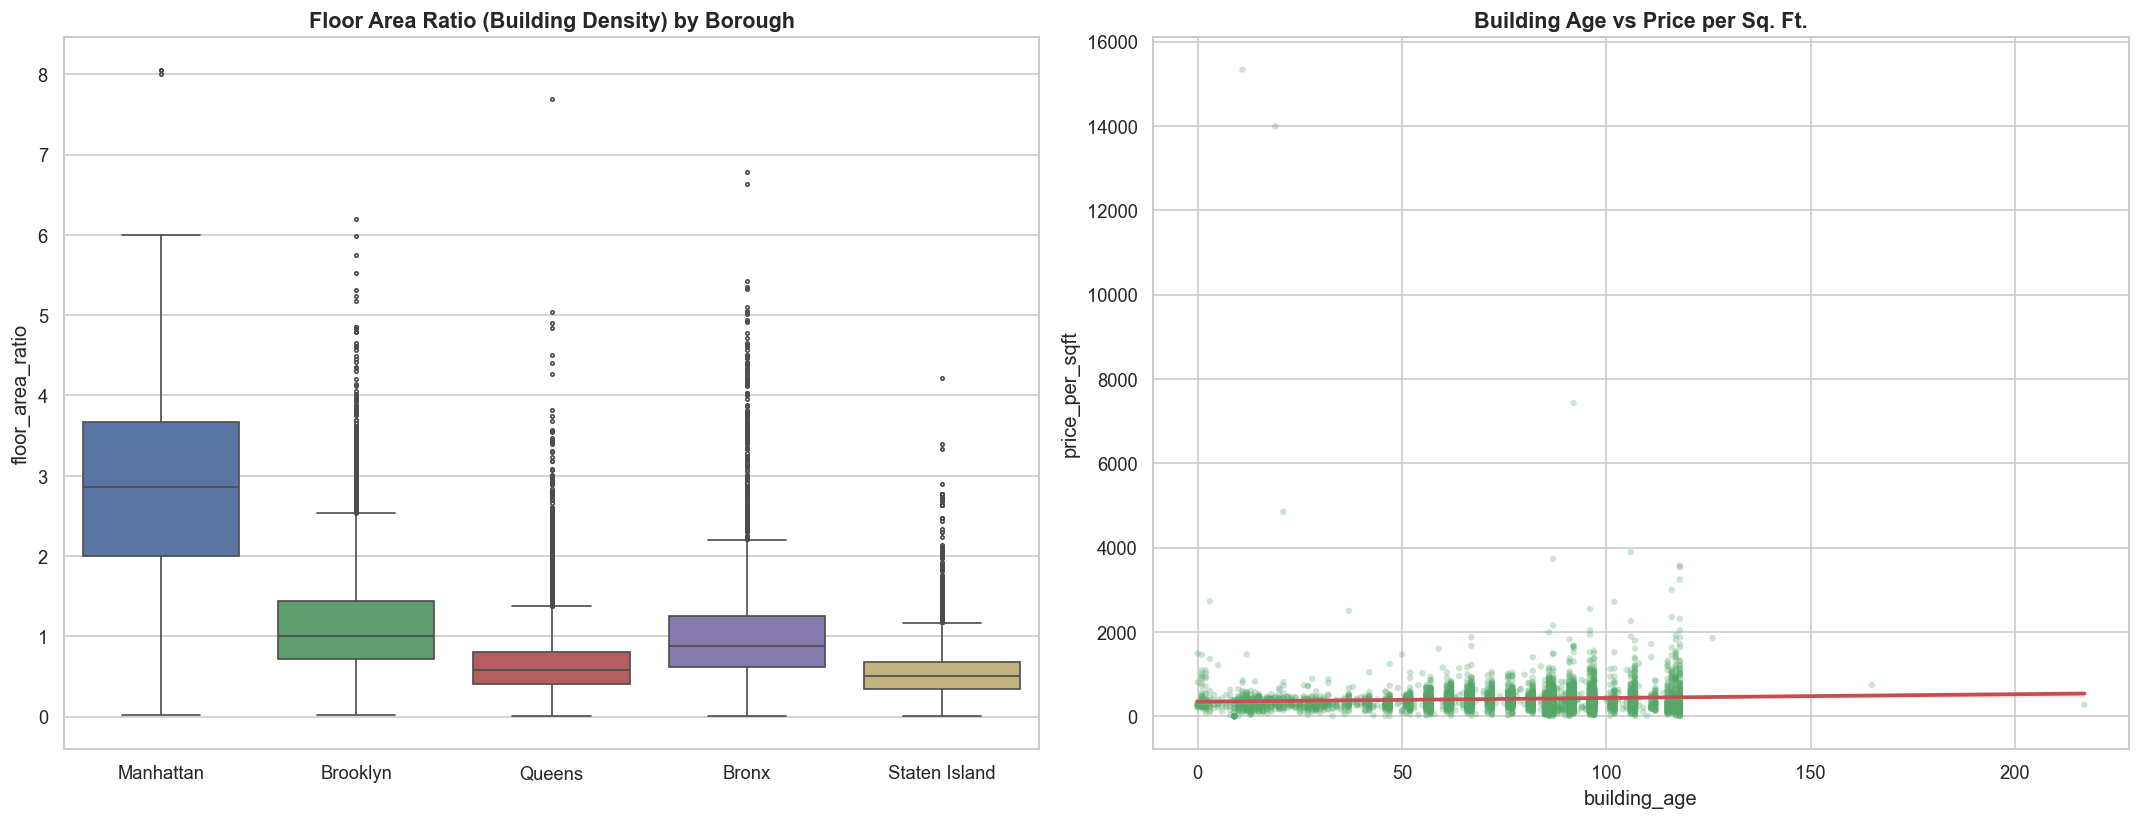

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Floor Area Ratio by Borough
sns.boxplot(data=df, x='borough_name', y='floor_area_ratio', order=BORO_ORD, palette=PAL, fliersize=2, ax=axes[0])
axes[0].set_title('Floor Area Ratio (Building Density) by Borough'); axes[0].set_xlabel('')

# Building Age vs Price/sqft
sample2 = df.dropna(subset=['building_age','price_per_sqft']).sample(min(5000, len(df)), random_state=42)
sns.scatterplot(data=sample2, x='building_age', y='price_per_sqft', alpha=0.3, color=PAL[1], s=15, ax=axes[1], edgecolor='none')
sns.regplot(data=sample2, x='building_age', y='price_per_sqft', scatter=False, color=PAL[2], ax=axes[1])
axes[1].set_title('Building Age vs Price per Sq. Ft.')

plt.tight_layout(); plt.show()

> Manhattan has the highest density (FAR). The age-vs-price scatter reveals a U-shape: brand-new and 100+ yr pre-war buildings both command premium pricing.

## 5 · Time-Based Analysis

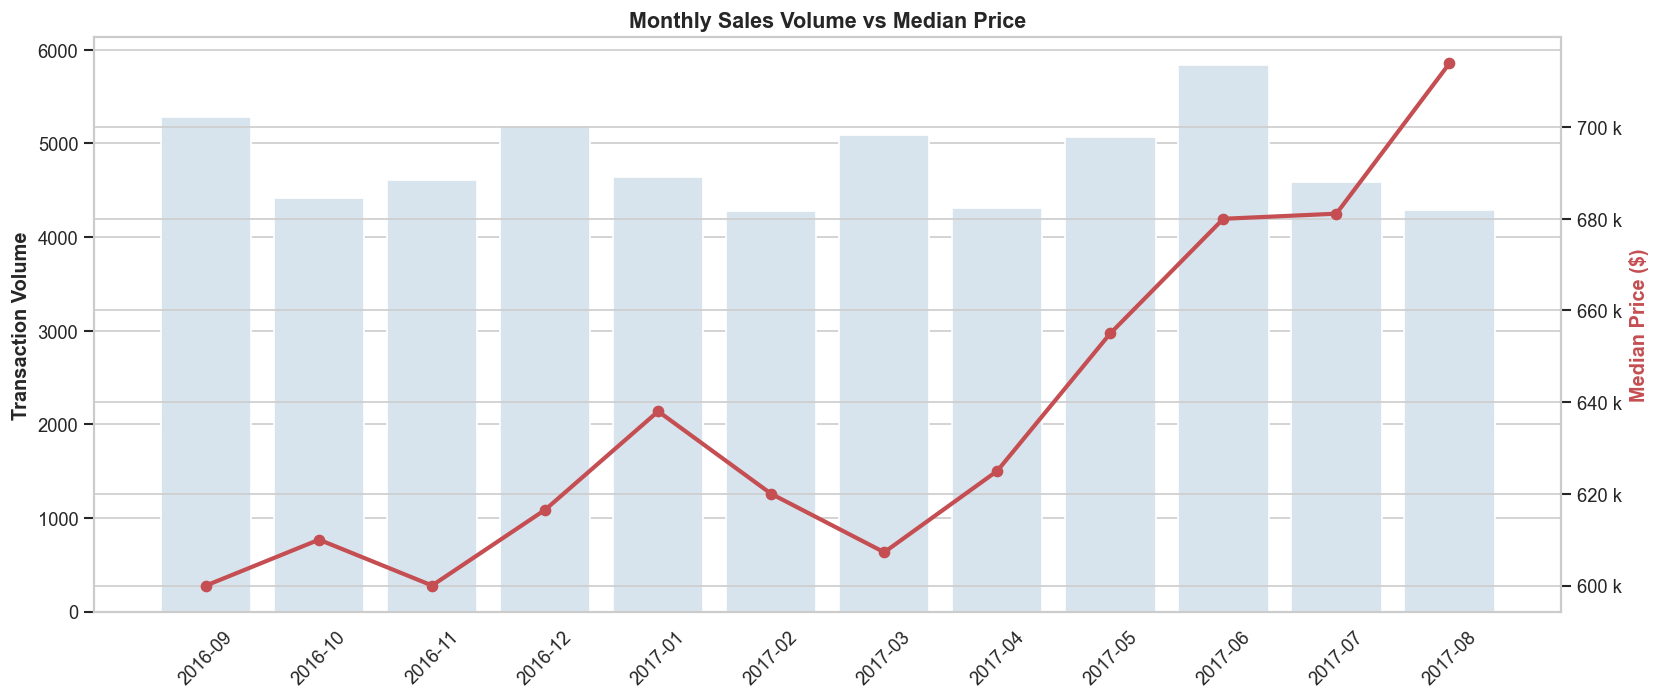

In [7]:
monthly = df.groupby(['sale_year','sale_month']).agg(
    volume=('sale_price','count'), median_price=('sale_price','median')
).reset_index()
monthly['ym'] = monthly['sale_year'].astype(str) + '-' + monthly['sale_month'].astype(str).str.zfill(2)
monthly = monthly.sort_values(['sale_year','sale_month'])

fig, ax1 = plt.subplots(figsize=(14, 6))
sns.barplot(data=monthly, x='ym', y='volume', color='#D5E4F0', ax=ax1)
ax1.set_ylabel('Transaction Volume', fontweight='bold')
ax1.set_xlabel(''); ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(range(len(monthly)), monthly['median_price'], color=PAL[2], marker='o', lw=2.5)
ax2.set_ylabel('Median Price ($)', fontweight='bold', color=PAL[2])
ax2.yaxis.set_major_formatter(mtick.EngFormatter())

plt.title('Monthly Sales Volume vs Median Price', fontweight='bold')
plt.tight_layout(); plt.show()

> Volume peaks in summer (June) and drops hard in winter (Jan/Feb). However, median prices remain stable year-round — sellers hold rather than discount during slow months.

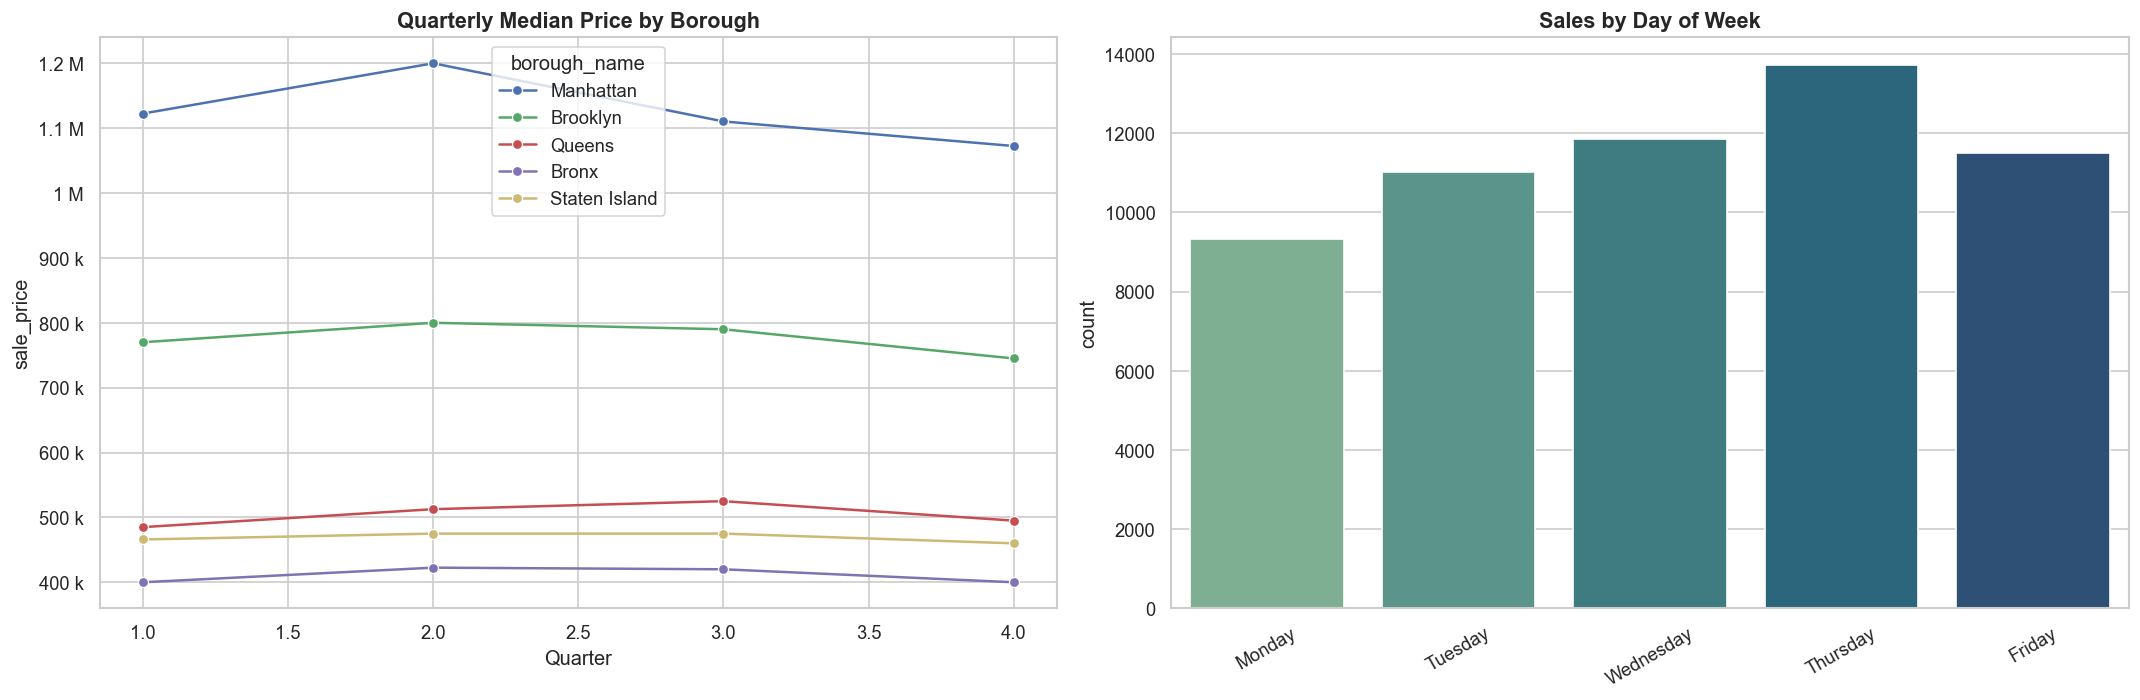

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Median price by quarter per borough
q_df = df.groupby(['borough_name','sale_quarter'])['sale_price'].median().reset_index()
sns.lineplot(data=q_df, x='sale_quarter', y='sale_price', hue='borough_name',
             hue_order=BORO_ORD, palette=PAL, marker='o', ax=axes[0])
axes[0].set_title('Quarterly Median Price by Borough')
axes[0].yaxis.set_major_formatter(mtick.EngFormatter()); axes[0].set_xlabel('Quarter')

# Day of week distribution
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday']
sns.countplot(data=df[df['sale_day_of_week'].isin(dow_order)], x='sale_day_of_week', order=dow_order, palette='crest', ax=axes[1])
axes[1].set_title('Sales by Day of Week'); axes[1].set_xlabel(''); axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout(); plt.show()

> Quarterly trends vary by borough — Manhattan shows more volatility than outer boroughs. Most transactions close mid-week (Tue–Thu), likely reflecting business-hour closings.

## 6 · Correlation Analysis

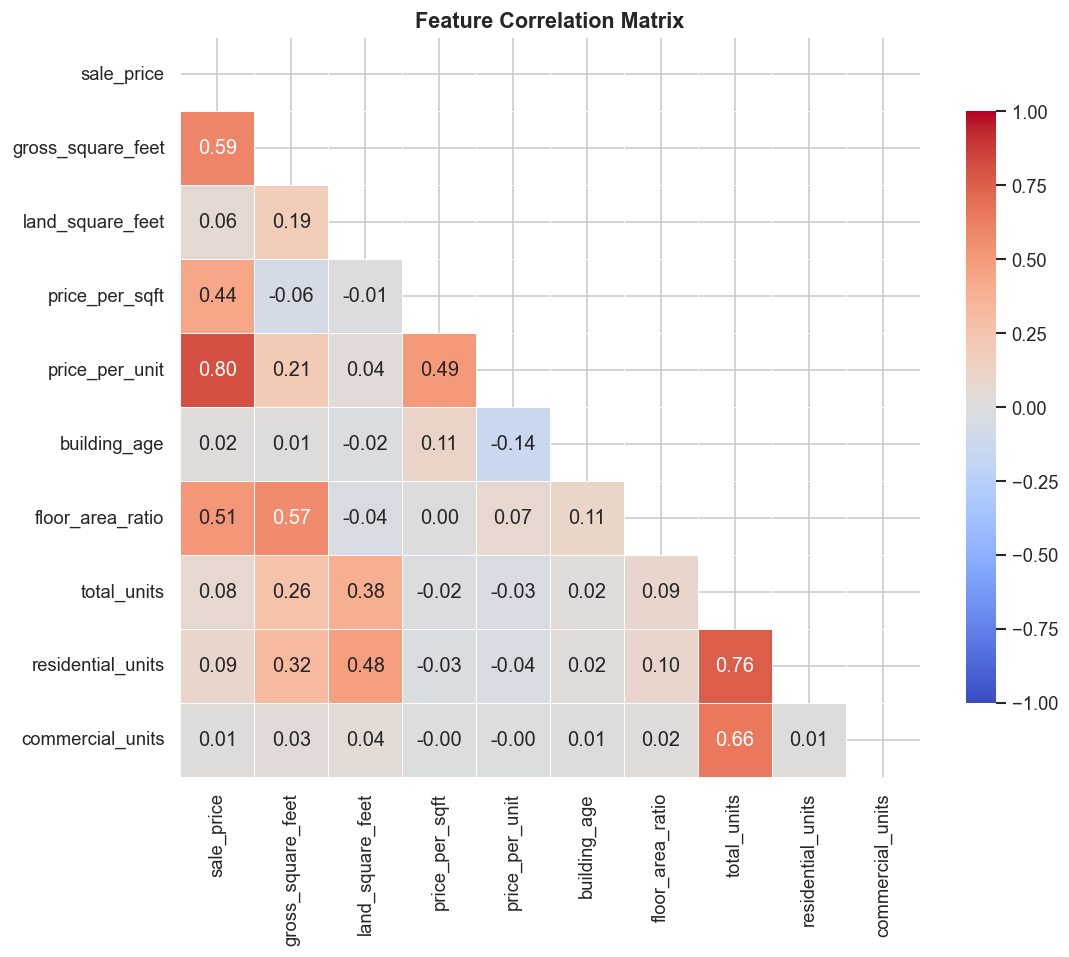

In [9]:
corr_cols = ['sale_price','gross_square_feet','land_square_feet','price_per_sqft',
             'price_per_unit','building_age','floor_area_ratio','total_units',
             'residential_units','commercial_units']
valid = [c for c in corr_cols if c in df.columns]
corr = df[valid].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', square=True,
            vmin=-1, vmax=1, linewidths=.5, cbar_kws={'shrink': .8})
plt.title('Feature Correlation Matrix', fontweight='bold')
plt.show()

> `gross_square_feet` and `total_units` are the strongest linear predictors of sale price. The engineered `price_per_sqft` validates correctly. `building_age` has near-zero linear correlation — confirming it needs non-linear treatment in modeling.